# Preparation

In [532]:
def parse_fleet(file):
    with open(file,"r") as f:
        lines = [line.strip() for line in f if line.strip()]
    i=0
    while i<len(lines):
        parts=lines[i].split()
        if "cvrp" in file:
            if len(parts)==1:
                vehcile_capacity=int(parts[0])
                coordinates=lines[i+1].split()
                x_coordinate=float(coordinates[0])
                y_coordinate=float(coordinates[1])
                customers=[]
                for j in range(i+2,len(lines)):
                    each_line=lines[j].split()
                    customers.append({
                        "id": j-2,
                        "x_coordinate":float(each_line[0]),
                        "y_coordinate":float(each_line[1]),
                        "demand":int(each_line[2])
                    })
                return {
                    "vehicle_capacity":vehcile_capacity,
                    "depot_coordinates":(x_coordinate,y_coordinate),
                    "customers":customers
                }
        if "vrptw" in file:
          if len(parts)==2:
                number_of_vehicles=int(parts[0])
                vehcile_capacity=int(parts[1])
                coordinates=lines[i+1].split()
                x_coordinate=float(coordinates[0])
                y_coordinate=float(coordinates[1])
                customers=[]
                for j in range(i+2,len(lines)):
                    each_line=lines[j].split()
                    customers.append({
                        "id": j-2,
                        "x_coordinate":float(each_line[0]),
                        "y_coordinate":float(each_line[1]),
                        "demand":int(each_line[2]),
                        "time_window_opening":float(each_line[3]),
                        "time_window_closing":float(each_line[4]),
                        "service_time": float(each_line[5])
                    })
                return {
                    "number_of_vehicles": number_of_vehicles,
                    "vehicle_capacity":vehcile_capacity,
                    "depot_coordinates":(x_coordinate,y_coordinate),
                    "customers":customers
                }
                
        i+=1
    return None

# VRPTW Problem
## Addressing problems
- Fitness function: Total distance traveled by all vehicles
- Constraints:
    - Each customer is visited exactly once: Try adding more customer stops to each vehicle until the vehicle can no longer make the time window for any customer OR until the vehicle reaches its capacity. If a found solution doesn't visit every customer, we rebuild another solution until we find one that does.
    - Each vehicle starts and ends at the depot


In [533]:
instance = parse_fleet("vrptw.txt")
instance

{'number_of_vehicles': 25,
 'vehicle_capacity': 200,
 'depot_coordinates': (35.0, 35.0),
 'customers': [{'id': 0,
   'x_coordinate': 41.0,
   'y_coordinate': 49.0,
   'demand': 10,
   'time_window_opening': 161.0,
   'time_window_closing': 171.0,
   'service_time': 10.0},
  {'id': 1,
   'x_coordinate': 35.0,
   'y_coordinate': 17.0,
   'demand': 7,
   'time_window_opening': 50.0,
   'time_window_closing': 60.0,
   'service_time': 10.0},
  {'id': 2,
   'x_coordinate': 55.0,
   'y_coordinate': 45.0,
   'demand': 13,
   'time_window_opening': 116.0,
   'time_window_closing': 126.0,
   'service_time': 10.0},
  {'id': 3,
   'x_coordinate': 55.0,
   'y_coordinate': 20.0,
   'demand': 19,
   'time_window_opening': 149.0,
   'time_window_closing': 159.0,
   'service_time': 10.0},
  {'id': 4,
   'x_coordinate': 15.0,
   'y_coordinate': 30.0,
   'demand': 26,
   'time_window_opening': 34.0,
   'time_window_closing': 44.0,
   'service_time': 10.0},
  {'id': 5,
   'x_coordinate': 25.0,
   'y_coord

In [534]:
class Customer:
    def __init__(self, id, x, y, demand, opening, closing, service_time) -> None:
        self.id = id
        self.x = x
        self.y = y
        self.demand = demand
        self.opening = opening
        self.closing = closing
        self.service_time = service_time

class VehicleStop:
    def __init__(self, customer_id, x, y, arrival_time, departure_time, remaining_capacity) -> None:
        self.customer_id = customer_id
        self.x = x
        self.y = y
        self.arrival_time = arrival_time
        self.departure_time = departure_time
        self.remaining_capacity = remaining_capacity

class VehicleSchedule:
    def __init__(self, vehicle_id, stops: list[VehicleStop]) -> None:
        self.vehicle_id = vehicle_id
        self.stops = stops

    def __repr__(self) -> str:
        return f"{self.vehicle_id}: {self.stops}"

class Solution:
    def __init__(self, schedules: list[VehicleSchedule]) -> None:
        self.schedules = schedules

    def __repr__(self) -> str:
        return f"{self.schedules}"

## GRASP as a baseline
1. Build a solution using a greedy randomized algorithm. When building a solution, we make sure that the schedule is valid and we do not need to check for feasibility afterwards (and use a repair function). We use an alpha parameter to control how greedy/random a solution is.
2. Apply local (neighborhood) search with on a given solution to find the best version of that solution (hill-climb to the local optimum). A neighbor of a solution is a solution that can be generated by changing the position of exactly one customer stop in a schedule.
3. Repeat steps 1 and 2 for a given number of iterations, and keep track of the best solution found.

In [ ]:
import math
import random

def euclidean_distance(start_x, start_y, end_x, end_y):
    return math.sqrt((end_x - start_x) ** 2 + (end_y - start_y) ** 2)

def route_distance(stops: list[VehicleStop], depot_coordinates: tuple[float, float]) -> float:
    """Calculate distance for the route of a vehicle"""
    if not stops:
        return 0.0
    dist = 0.0
    last_x, last_y = depot_coordinates
    for s in stops:
        dist += euclidean_distance(last_x, last_y, s.x, s.y)
        last_x, last_y = s.x, s.y
    return dist

def solution_cost(solution: Solution, depot_coordinates: tuple[float, float]) -> float:
    """Calculate cost of a solution"""
    return sum(route_distance(schedule.stops, depot_coordinates) for schedule in solution.schedules)

def build_solution_from_routes(routes: list[list[int]], customers: list[Customer], vehicle_capacity: int) -> Solution | None:
    """
    Rebuild a Solution from route customer-id sequences.
    Returns None if any route violates capacity/time-window feasibility.
    """
    customer_by_id = {c.id: c for c in customers}
    visited_customer_ids = set[int]()
    schedules: list[VehicleSchedule] = []

    for vehicle_id, route in enumerate(routes):
        stops: list[VehicleStop] = []
        remaining_capacity = vehicle_capacity
        last_departure = 0.0

        for customer_id in route:
            c = customer_by_id[customer_id]
            visited_customer_ids.add(customer_id)

            if c.demand > remaining_capacity:
                return None

            arrival = max(last_departure, c.opening)
            if arrival > c.closing:
                return None

            departure = arrival + c.service_time
            remaining_capacity -= c.demand

            stops.append(
                VehicleStop(
                    customer_id=c.id,
                    x=c.x,
                    y=c.y,
                    arrival_time=arrival,
                    departure_time=departure,
                    remaining_capacity=remaining_capacity
                )
            )
            last_departure = departure

        schedules.append(VehicleSchedule(vehicle_id, stops))

    # valid solution must visit every customer exactly once
    if len(visited_customer_ids) != len(customers):
        return None

    return Solution(schedules)

def local_search(solution: Solution, customers: list[Customer], depot_coordinates, vehicle_capacity) -> tuple[Solution, float]:
    """
    Searches for neighbors with a higher score and returns the local optimum.
    Uses the first better solution that is found.
    """
    best = solution
    best_cost = solution_cost(best, depot_coordinates)

    improved = True
    while improved:
        improved = False
        routes: list[list[int]] = [[s.customer_id for s in schedule.stops] for schedule in solution.schedules]

        for vehicle_i in range(len(routes)):
            for customer_i in range(len(routes[vehicle_i])):
                customer_id = routes[vehicle_i][customer_i]
                for vehicle_j in range(len(routes)):
                    for customer_j in range(len(routes[vehicle_j]) + 1):
                        if vehicle_i == vehicle_j and (customer_j == customer_i or customer_j == customer_i + 1):
                            continue
                        # deep copy routes
                        new_routes = [route.copy() for route in routes]
                        new_routes[vehicle_i].pop(customer_i)
                        # account for the index shift after popping from the route and inserting in the same router at a later index
                        insert_pos = customer_j - 1 if vehicle_i == vehicle_j and customer_j > customer_i else customer_j
                        new_routes[vehicle_j].insert(insert_pos, customer_id)

                        cand = build_solution_from_routes(new_routes, customers, vehicle_capacity)
                        if cand is None:
                            continue
                        cand_cost = solution_cost(cand, depot_coordinates)
                        if cand_cost < best_cost:
                            best, best_cost = cand, cand_cost
                            improved = True
                            break
                    if improved: break
                if improved: break
            if improved: break

    return best, best_cost

def build_grasp_solution(number_of_vehicles, vehicle_capacity, depot_coordinates, customers: list[Customer], alpha) -> Solution | None:
    """Build a solution from scratch with a greedy randomized algorithm"""
    not_visited_customers = customers.copy()
    schedules: list[VehicleSchedule] = []
    starting_point = VehicleStop(-1 , depot_coordinates[0], depot_coordinates[1], 0, 0, vehicle_capacity)

    # iterate over every vehicle and create a schedule for it
    for i in range(number_of_vehicles):
        stops: list[VehicleStop] = []
        current_capacity = vehicle_capacity
        # add stops to the schedule until we cannot guarantee time windows are met anymore
        feasible_customers = not_visited_customers
        while len(feasible_customers):
            last_stop = stops[-1] if len(stops) > 0 else starting_point
            # calculate cost for every customer and create RCL list
            cost_by_id = {
                c.id: euclidean_distance(last_stop.x, last_stop.y, c.x, c.y)
                for c in feasible_customers
            }

            min_cost = min(cost_by_id.values())
            max_cost = max(cost_by_id.values())
            threshold = min_cost + alpha * (max_cost - min_cost)

            rcl: list[Customer] = [c for c in feasible_customers if cost_by_id[c.id] <= threshold]
            chosen = random.choice(rcl)
            arrival = max(chosen.opening, last_stop.departure_time)
            next_stop = VehicleStop(
                chosen.id, 
                chosen.x, 
                chosen.y, 
                arrival, 
                arrival + chosen.service_time, 
                current_capacity - chosen.demand
            )
            
            stops.append(next_stop)
            not_visited_customers.remove(chosen)
            current_capacity = next_stop.remaining_capacity
            feasible_customers = [
                c for c in not_visited_customers
                if next_stop.departure_time <= c.closing
                and c.demand <= current_capacity
            ]
        
        vehicle_schedule = VehicleSchedule(i, stops)
        schedules.append(vehicle_schedule)
    
    if not_visited_customers:
        return None

    return Solution(schedules)

def grasp(number_of_vehicles, vehicle_capacity, depot_coordinates, customers: list[Customer], alpha: float, max_iterations: int) -> tuple[Solution, float]:
    best_solution: Solution
    best_cost = float("inf")

    # iteratively build solutions and hill-climb to the nearest local optimum
    # save and return the best solution
    for _ in range(max_iterations):
        candidate: Solution | None = None
        while candidate is None:
            candidate = build_grasp_solution(number_of_vehicles, vehicle_capacity, depot_coordinates, customers, alpha)
        candidate, cost = local_search(candidate, customers, depot_coordinates, vehicle_capacity)
        
        if cost < best_cost:
            best_solution = candidate
            best_cost = cost

    return best_solution, best_cost # type: ignore

## ACO
1. Initialise pheromone trails to positive value (correspond to the quantity of pheromone on the edges between each node, with 0 values on the diagonal of the matrix). Too low values will lead to greedy solutions, while too high values will delay useful search until sufficient evaporation has occurred.
2. For each ant, construct a solution and measure quality.
3. Update pheromone trails based on pheromone deposit and evaporation.

In [ ]:
def build_aco_solution(number_of_vehicles, vehicle_capacity, depot_coordinates, customers: list[Customer], alpha, beta, heuristic_matrix: list[list[float]], pheromone_matrix: list[list[float]]) -> Solution | None:
    """Build a solution from scratch"""
    not_visited_customers = customers.copy()
    schedules: list[VehicleSchedule] = []
    starting_point = VehicleStop(-1 , depot_coordinates[0], depot_coordinates[1], 0, 0, vehicle_capacity)

    # iterate over every vehicle and create a schedule for it
    for i in range(number_of_vehicles):
        stops: list[VehicleStop] = []
        current_capacity = vehicle_capacity
        # add stops to the schedule until we cannot guarantee time windows are met anymore
        feasible_customers = not_visited_customers
        while len(feasible_customers):
            last_stop = stops[-1] if len(stops) > 0 else starting_point
            # get cost for every customer
            pheromone_row: list[float] = pheromone_matrix[last_stop.customer_id + 1]
            heuristic_row: list[float] = heuristic_matrix[last_stop.customer_id + 1]
            # calculate probabilities
            total = sum((pheromone_row[c.id + 1] ** alpha) * (heuristic_row[c.id + 1] ** beta) for c in feasible_customers)
            feasible_probabilities = [(pheromone_row[c.id + 1] ** alpha) * (heuristic_row[c.id + 1] ** beta) / total for c in feasible_customers]
            # chose random next stop according to probabilities
            chosen = random.choices(feasible_customers, weights=feasible_probabilities, k=1)[0]

            arrival = max(chosen.opening, last_stop.departure_time)
            next_stop = VehicleStop(
                chosen.id, 
                chosen.x, 
                chosen.y, 
                arrival, 
                arrival + chosen.service_time, 
                current_capacity - chosen.demand
            )
            
            stops.append(next_stop)
            not_visited_customers.remove(chosen)
            current_capacity = next_stop.remaining_capacity
            feasible_customers = [
                c for c in not_visited_customers
                if next_stop.departure_time <= c.closing
                and c.demand <= current_capacity
            ]
        
        vehicle_schedule = VehicleSchedule(i, stops)
        schedules.append(vehicle_schedule)
    
    if not_visited_customers:
        return None

    return Solution(schedules)

def update_pheromones(pheromone_matrix, solutions, costs, evaporation_rate):
    n = len(pheromone_matrix)

    for i in range(n):
        for j in range(n):
            # all paths slowly evaporate with time
            pheromone_matrix[i][j] *= (1 - evaporation_rate)

    for solution, cost in zip(solutions, costs):
        # more pheromone deposit for better solutions
        deposit_amount = 1 / cost

        for schedule in solution.schedules:
            stops = schedule.stops

            if not stops:
                continue

            # add pheromone throughout the entire path that the ant has walked
            prev = 0
            for stop in stops:
                curr = stop.customer_id + 1
                pheromone_matrix[prev][curr] += deposit_amount
                pheromone_matrix[curr][prev] += deposit_amount
                prev = curr

def aco(number_of_vehicles, vehicle_capacity, depot_coordinates, customers: list[Customer], alpha, beta, number_of_iterations, number_of_ants, evaporation_rate) -> tuple[Solution, float]:
    depot_dummy = Customer(-1, depot_coordinates[0], depot_coordinates[1], 0, 0, 0, 0)
    nodes = [depot_dummy] + customers
    n = len(nodes)
    distance_matrix = [[euclidean_distance(nodes[i].x, nodes[i].y, nodes[j].x, nodes[j].y) for j in range(n)] for i in range(n)]
    heuristic_matrix = [[0 if i == j else 1 / distance_matrix[i][j] for j in range(n)] for i in range(n)]
    pheromone_matrix = [[1.0 for _ in range(n)] for _ in range(n)]

    best_solution: Solution
    best_cost = float("inf")
    iteration_solutions = list[Solution]()
    iteration_costs = list[float]()
    for _ in range(number_of_iterations):
        for i in range(number_of_ants):
            candidate: Solution | None = None
            while candidate is None:
                candidate = build_aco_solution(number_of_vehicles, vehicle_capacity, depot_coordinates, customers, alpha, beta, heuristic_matrix, pheromone_matrix)
            cost = solution_cost(candidate, depot_coordinates)
            iteration_solutions.append(candidate)
            iteration_costs.append(cost)
        
            if cost < best_cost:
                best_solution = candidate
                best_cost = cost

        update_pheromones(pheromone_matrix, iteration_solutions, iteration_costs, evaporation_rate)
        iteration_solutions.clear()
        iteration_costs.clear()
    return best_solution, best_cost # type: ignore

## Run both algorithms

In [ ]:
number_of_vehicles = instance["number_of_vehicles"] # type: ignore
vehicle_capacity = instance["vehicle_capacity"] # type: ignore
depot_coordinates = instance["depot_coordinates"] # type: ignore
customer_dict = instance["customers"] # type: ignore

customers: list[Customer] = []
for c in customer_dict:
    customer = Customer(c["id"], c["x_coordinate"], c["y_coordinate"], c["demand"], c["time_window_opening"], c["time_window_closing"], c["service_time"])
    customers.append(customer)

# grasp
RANDOMNESS = 0.3
MAX_ITERS = 10
grasp_candidate, grasp_score = grasp(number_of_vehicles, vehicle_capacity, depot_coordinates, customers, RANDOMNESS, MAX_ITERS)

# aco
NUMBER_OF_ANTS = 25
NUMBER_OF_ITERATIONS = 20

# beta > alpha works much better
# this means, that its generally better to weight the heuristic higher than the pheromone information
ALPHA = 1
BETA = 3

# higher evaporation rate seems to work better
EVAPORATION_RATE = 0.8
aco_candidate, aco_score = aco(number_of_vehicles, vehicle_capacity, depot_coordinates, customers, ALPHA, BETA, NUMBER_OF_ITERATIONS, NUMBER_OF_ANTS, EVAPORATION_RATE)

print("Best GRASP result:", grasp_score, "Best ACO result:", aco_score)

1781.5740393171527 1560.9805654614725


## Visualization

In [541]:
import matplotlib.pyplot as plt

def plot_solution(solution: Solution, customers: list[Customer], depot_coordinates: tuple[float, float]):
    depot_x, depot_y = depot_coordinates

    all_x = [c.x for c in customers]
    all_y = [c.y for c in customers]
    all_ids = [c.id for c in customers]

    plt.figure(figsize=(10, 8))
    plt.scatter(all_x, all_y, c="lightgray", s=50, label="Customers", zorder=1)

    # customer id labels
    for cid, x, y in zip(all_ids, all_x, all_y):
        plt.text(x + 0.15, y + 0.15, str(cid), fontsize=8, color="gray")

    # Depot
    plt.scatter([depot_x], [depot_y], c="red", s=180, marker="*", label="Depot", zorder=5)

    cmap = plt.get_cmap("tab20")

    for schedule in solution.schedules:
        if not schedule.stops:
            continue

        color = cmap(schedule.vehicle_id % 20)

        route_x = [depot_x] + [s.x for s in schedule.stops]
        route_y = [depot_y] + [s.y for s in schedule.stops]

        plt.plot(
            route_x,
            route_y,
            color=color,
            linewidth=2,
            marker="o",
            markersize=4,
            label=f"Vehicle {schedule.vehicle_id}",
            zorder=3
        )

    plt.title("VRPTW Solution: Vehicle Routes")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(alpha=0.25)
    plt.legend(loc="best", fontsize=8)
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

## Results

### Plot GRASP solution

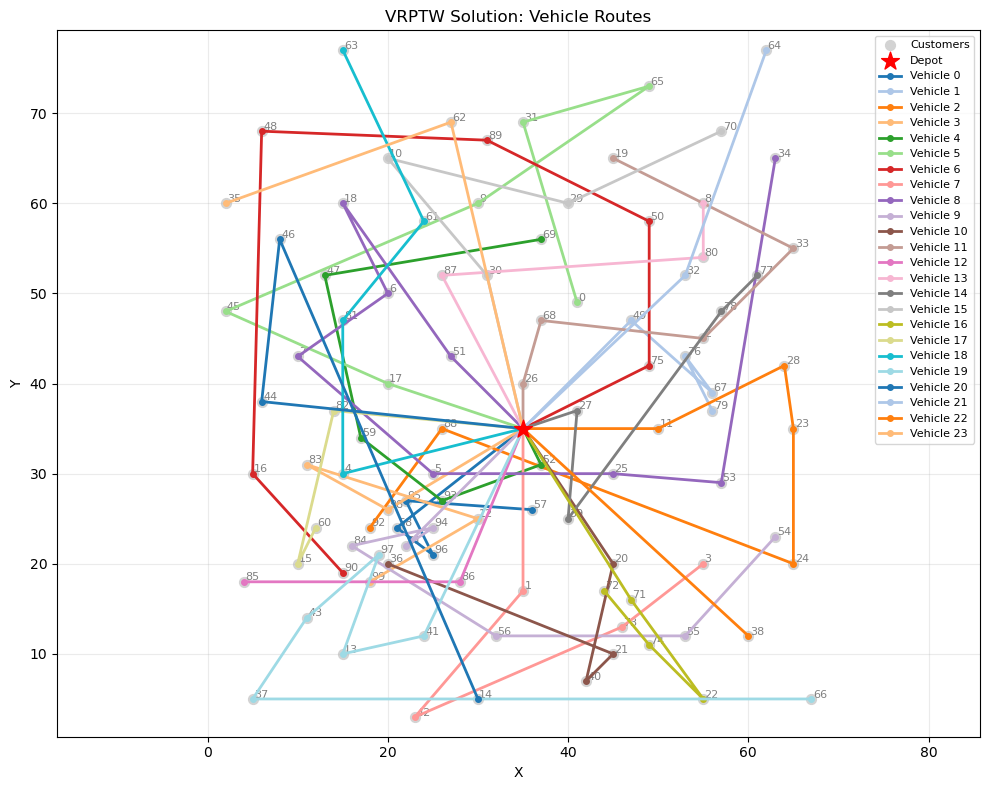

In [542]:
plot_solution(grasp_candidate, customers, depot_coordinates)

### Plot ACO solution

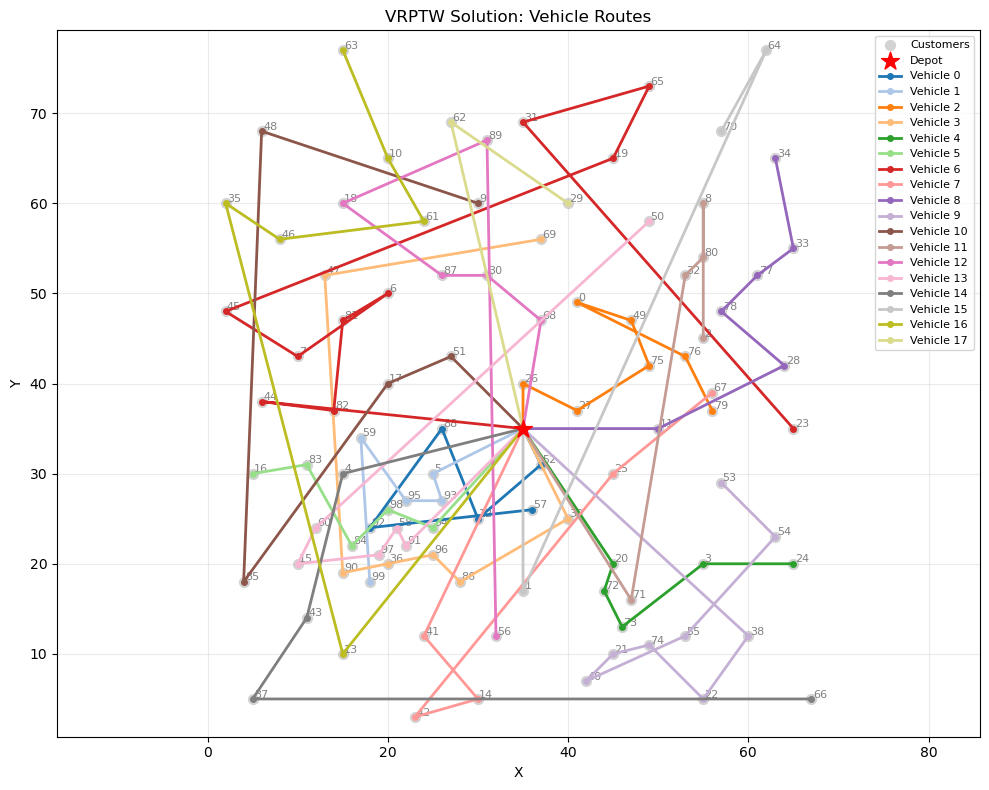

In [543]:
plot_solution(aco_candidate, customers, depot_coordinates)

### Conclusion
ACO works much faster than GRASP, and is also able to find better solutions when hyperparameters are tuned well. If the hyperparameters values are far apart from the optimal values, ACO can perform much worse than GRASP.

The reason why ACO is faster than GRASP is that the local search phase of GRASP is computationally very expensive, and ACO doesn't include that phase.

The reason why ACO usually finds better solutions than GRASP is because our GRASP implementation including the neighborhood search is very basic. Therefore, it is not able to explore the solution space as effectively as ACO.